# LABORATORIUM 8 - SIEĆ NEURONOWA

## 8.1 Uczenie i ewaluacja trójwarstwowej sieci neuronowej z ReLu i logistyczną funkcją aktywacji 

In [1]:
import numpy as np
from sklearn.datasets import make_blobs, make_classification, make_moons
from matplotlib.colors import ListedColormap
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_curve, auc
from matplotlib import pyplot as plt
import numpy as np
from collections import Counter
import math
import numpy as np
from sklearn.model_selection import train_test_split
import time


#### Funkcja generująca zbiory danych:

In [2]:
def generate_blobs(n_samples, n_features, random_state, split_data=[0, 2, 4]):
    centers_multi = [
        (-5, 5), (-5, 0), (-5, -5),  
        (5, 5), (5, 0), (5, -5)
    ]
    X_uni, y_uni = make_blobs(n_samples=n_samples, centers=centers_multi, n_features=n_features, random_state=random_state)
    y_uni = np.where(np.isin(y_uni, split_data), 0, 1)
    # y_uni = 2 * y_uni - 1
    return X_uni, y_uni

#### Funckja obliczająca metryki i statystyki:

In [3]:
def evaluate_classifier(y_test, y_pred, X, y, model, classifier_name, dataset_name, labels=[0,1], decision_plot=True):
    # Oblicz metryki
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = accuracy_score(y_test, y_pred)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)

    # Wyświetl metryki
    print(f"{classifier_name} na {dataset_name}:")
    print(f"Skuteczność: {accuracy*100:.4f}%")
    print(f"Czułość (Recall): {sensitivity*100:.4f}%")
    print(f"Swoistość: {specificity*100:.4f}%")
    print(f"ROC AUC: {roc_auc:.4f}")

    fig = plt.figure(figsize=(20, 6))
    plt.suptitle(f"WYNIKI DLA: {classifier_name} na zbiorze: {dataset_name}", fontsize=16, y=1.05)

    axes = fig.subplots(1, 3)

    # Macierz pomyłek
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=axes[0], cmap='Greens', colorbar=False)
    axes[0].set_title("Macierz pomyłek")

    # Krzywa ROC
    axes[1].plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    axes[1].plot([0, 1], [0, 1], 'k--') 
    axes[1].set_xlabel('1 - Swoistość (False Positive Rate)')
    axes[1].set_ylabel('Czułość (True Positive Rate)')
    axes[1].set_title('Krzywa ROC')
    axes[1].legend(loc='lower right')
    axes[1].grid(True)

    if decision_plot:
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                            np.arange(y_min, y_max, 0.01))
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        custom_cmap = ListedColormap(['red', 'blue'])
        axes[2].contourf(xx, yy, Z, alpha=0.4, cmap=custom_cmap)
        scatter = axes[2].scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=custom_cmap, s=50)
        axes[2].set_title("Granica decyzyjna")
        axes[2].set_xlabel("Feature 1")
        axes[2].set_ylabel("Feature 2")
        axes[2].grid(True)

    plt.tight_layout()
    plt.show()
    return accuracy, sensitivity, specificity, roc_auc

#### Sieć neuronowa:

In [4]:
class NeuralNetwork:
    def __init__(self, layers_sizes=[2, 10, 10, 2], act_fun='logistic', eta=0.01, max_epochs=1000):
        self.layers_sizes = layers_sizes
        self.n_layers = len(layers_sizes) - 1
        self.eta = eta
        self.act_function = act_fun
        self.max_epochs = max_epochs
        self.weights = []
        for i in range(self.n_layers):
            # print(f"Warstwa {i}: {layers_sizes[i]} -> {layers_sizes[i + 1]}")
            weight_matrix = np.random.randn(layers_sizes[i + 1], layers_sizes[i]) * np.sqrt(2 / layers_sizes[i + 1])
            self.weights.append(weight_matrix)
        self.biases = [np.zeros((1, size)) for size in layers_sizes[1:]]

    def logistic(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    def logistic_derivative(self, x):
        s = self.logistic(x)
        return s * (1 - s)
        
    def relu(self, x):
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        return np.where(x > 0, 1, 0)
    
    def leaky_relu(self, x):
        return np.where(x > 0, x, 0.01 * x)

    def leaky_relu_derivative(self, x):
        return np.where(x > 0, 1, 0.01)

    def activate(self, x):
        if self.act_function == 'logistic':
            return self.logistic(x)
        elif self.act_function == 'relu':
            return self.relu(x)
        elif self.act_function == 'leaky_relu':
            return self.leaky_relu(x)
        
    def activate_derivative(self, x):
        if self.act_function == 'logistic':
            return self.logistic_derivative(x)
        elif self.act_function == 'relu':
            return self.relu_derivative(x)
        elif self.act_function == 'leaky_relu':
            return self.leaky_relu_derivative(x)
    
    def forward(self, X):
        activations = [X]
        for i in range(self.n_layers):
            s = np.dot(activations[-1], self.weights[i].T) + self.biases[i]
            res = self.activate(s)
            activations.append(res)
        return activations

    def backward(self, X, y, activations):
        deltas = []
        error = activations[-1] - y  
        delta = error * self.activate_derivative(activations[-1])
        deltas.append(delta)
        # print(f"Delta ostatniej warstwy: {np.mean(np.abs(delta))}")

        for i in range(self.n_layers - 1, 0, -1):
            error = np.dot(deltas[-1], self.weights[i]) 
            delta = error * self.activate_derivative(activations[i])
            deltas.append(delta)
            # print(f"Delta warstwy {i}: {np.mean(np.abs(delta))}")

        deltas.reverse()
        return deltas
    
    def adjust_weights(self, X, activations, deltas):
        for i in range(self.n_layers):
            self.weights[i] -= self.eta * np.dot(deltas[i].T, activations[i]) / X.shape[0]
            self.biases[i] -= self.eta * np.sum(deltas[i], axis=0, keepdims=True) / X.shape[0]
            
    def train(self, X, y):
        y = np.eye(self.weights[-1].shape[0])[y]
        for epoch in range(self.max_epochs):
            activations = self.forward(X)
            deltas = self.backward(X, y, activations)
            self.adjust_weights(X, activations, deltas)

    def predict(self, X):
        activations = self.forward(X)
        return np.argmax(activations[-1], axis=1)

#### Przygotowanie danych:

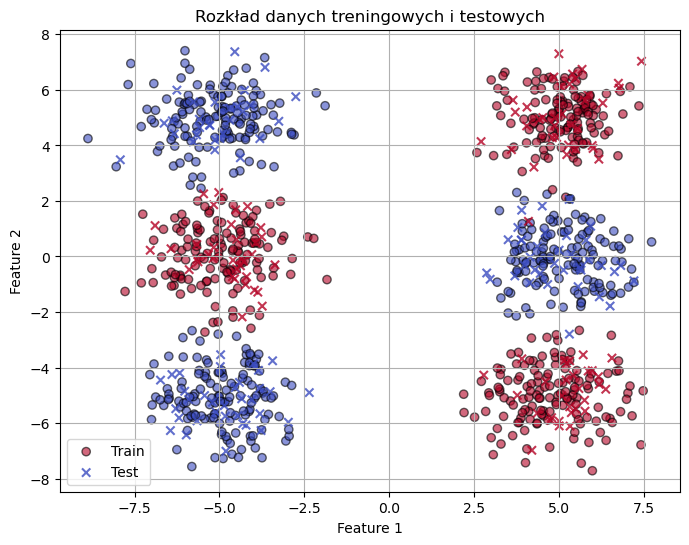

In [5]:
from sklearn.preprocessing import MinMaxScaler

X, y = generate_blobs(n_samples=1000, n_features=2, random_state=259195, split_data=[0, 2, 4])
# scaler = MinMaxScaler()
# X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=259195)

plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', label='Train', alpha=0.6, edgecolor='k')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', marker='x', label='Test', alpha=0.8)
plt.title('Rozkład danych treningowych i testowych')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

#### Dla funkcji *sigmoid*:

Czas wykonania: 7.54410 s.
ModularNN na Blobs Dataset:
Skuteczność: 95.0000%
Czułość (Recall): 95.0495%
Swoistość: 94.9495%
ROC AUC: 0.9500


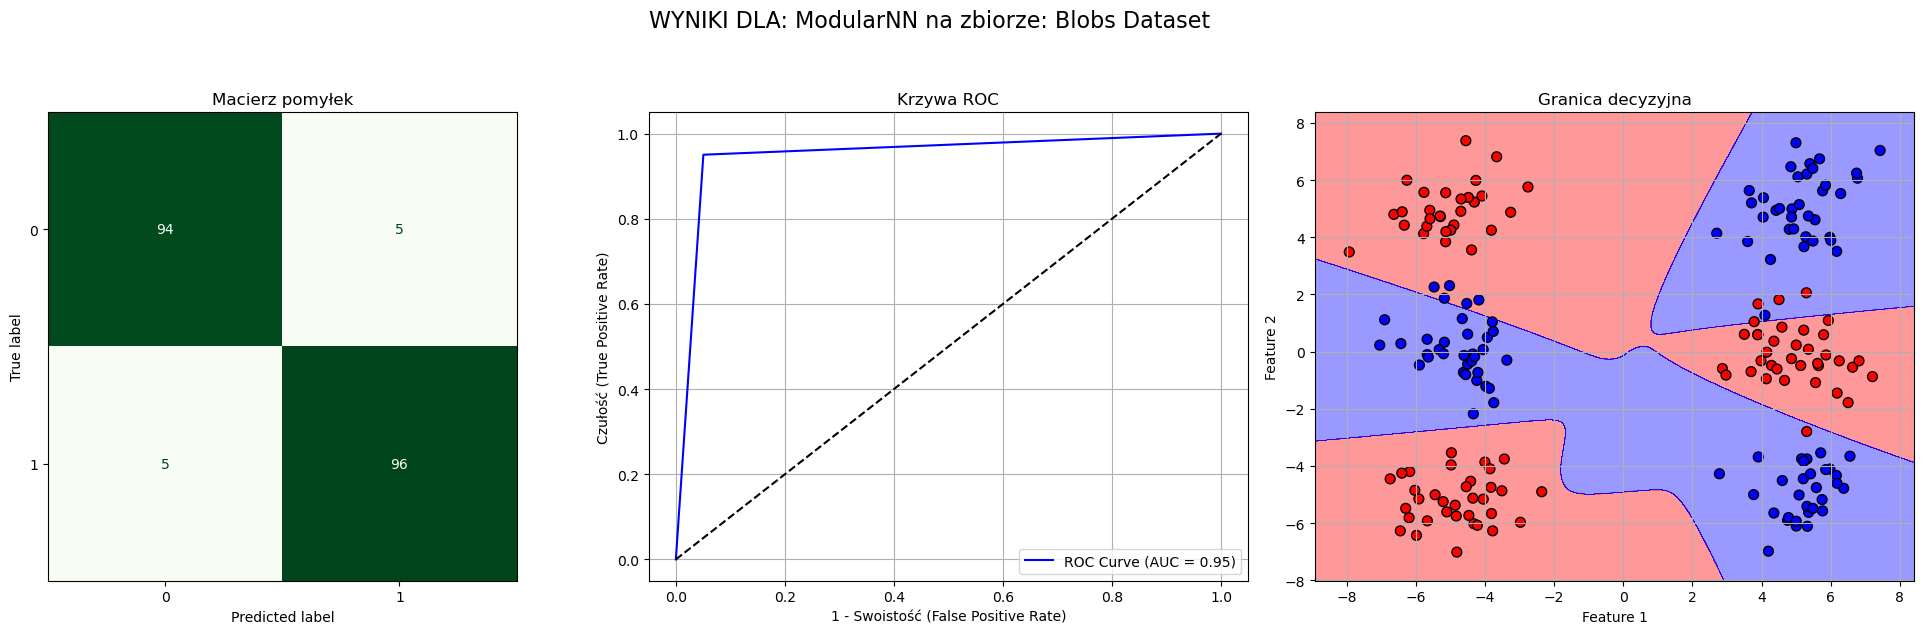

In [6]:
start = time.time()
for i in range(1):
    nn = NeuralNetwork(layers_sizes=[2, 10, 10, 2], act_fun='logistic', eta=0.1, max_epochs=10000)
    nn.train(X_train, y_train)
    y_pred = nn.predict(X_test)
end = time.time()
print(f"Czas wykonania: {end - start:.5f} s.")
acc, sensitivity, specificity, roc_auc = evaluate_classifier(
y_test, y_pred, X_test, y_test, nn, "ModularNN", "Blobs Dataset", labels=[0, 1], decision_plot=True)

#### Dla funkcji *ReLU / leaky ReLU*:

Czas wykonania: 1.92495s.
ModularNN na Blobs Dataset:
Skuteczność: 97.0000%
Czułość (Recall): 97.0297%
Swoistość: 96.9697%
ROC AUC: 0.9700


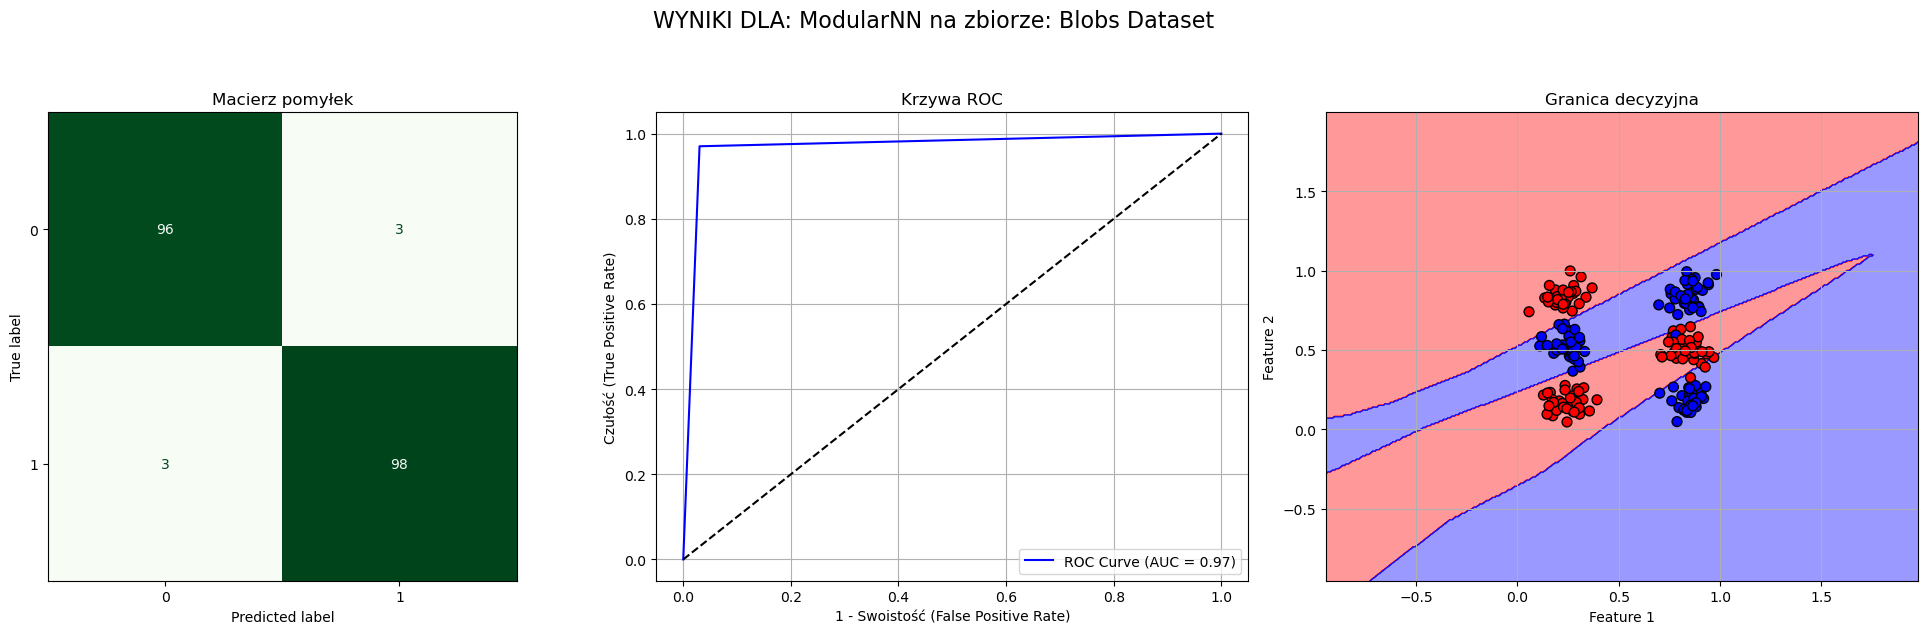

In [7]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

start = time.time()
for i in range(1):
    nn = NeuralNetwork(layers_sizes=[2, 10, 10, 2], act_fun='leaky_relu', eta=0.01, max_epochs=5000)
    nn.train(X_train, y_train)
    y_pred = nn.predict(X_test)
end = time.time()
print(f"Czas wykonania: {end - start:.5f}s.")
acc, sensitivity, specificity, roc_auc = evaluate_classifier(
y_test, y_pred, X_test, y_test, nn, "ModularNN", "Blobs Dataset", labels=[0, 1], decision_plot=True)

#### Wnioski i obserwacje: 

* W obu przypadkach dla wielomodalnych i nieseparowalnych liniowo danych algorytm sieci potrzebuje sporej ilości epok by osiągnąć dobre wyniki.  

## 8.2 Modularna struktura sieci umożliwiająca ustalenie dowolnej ilości i szerokości warstw

#### Przykład 5-warstwowej sieci neuronowej

Czas wykonania: 2.84291s.
ModularNN na Blobs Dataset:
Skuteczność: 99.0000%
Czułość (Recall): 99.0099%
Swoistość: 98.9899%
ROC AUC: 0.9900


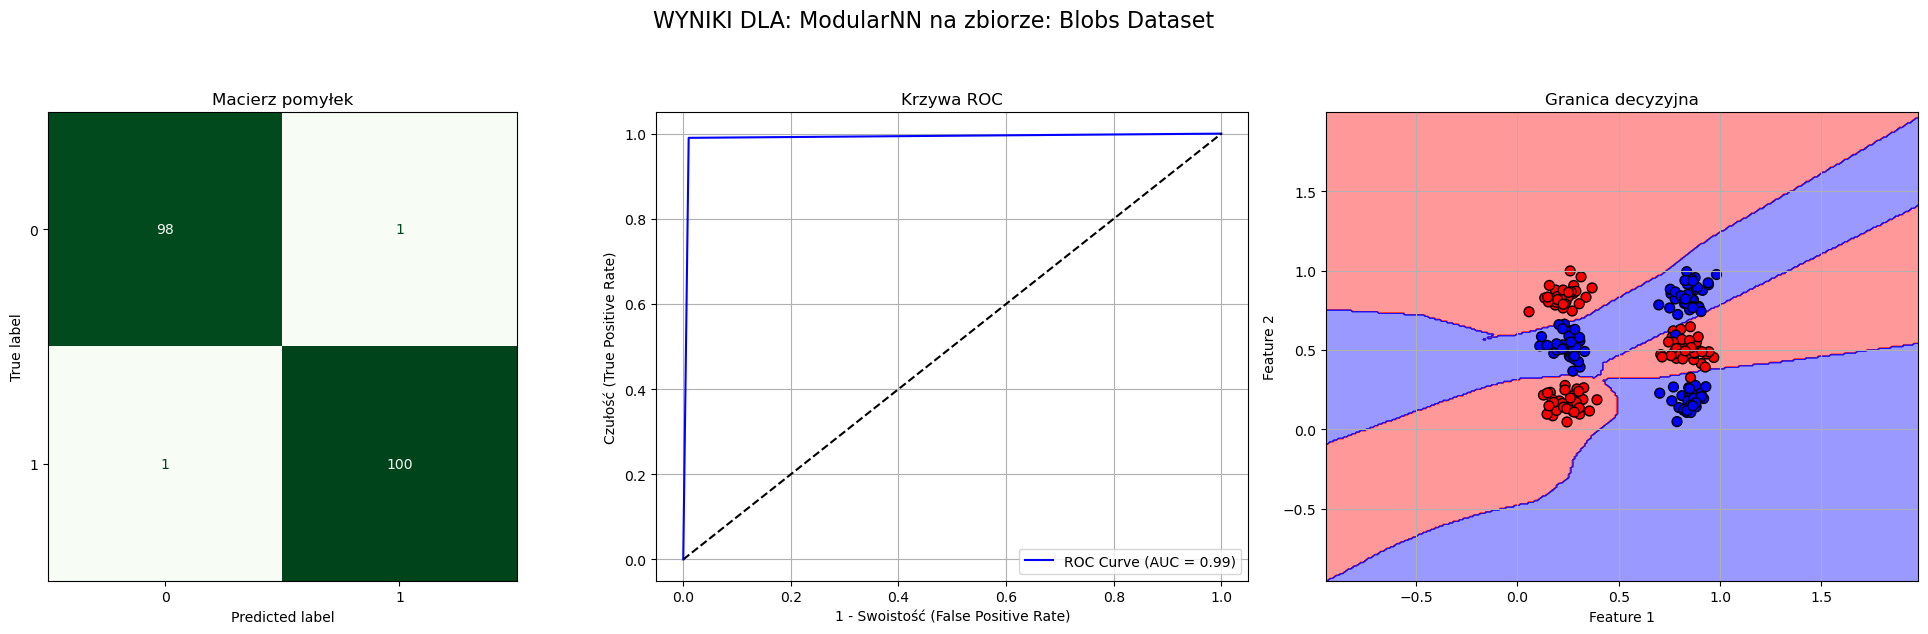

In [8]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

start = time.time()
for i in range(1):
    nn = NeuralNetwork(layers_sizes=[2, 10, 10, 10, 10, 2], act_fun='relu', eta=0.1, max_epochs=5000)
    nn.train(X_train, y_train)
    y_pred = nn.predict(X_test)
end = time.time()
print(f"Czas wykonania: {end - start:.5f}s.")
acc, sensitivity, specificity, roc_auc = evaluate_classifier(
y_test, y_pred, X_test, y_test, nn, "ModularNN", "Blobs Dataset", labels=[0, 1], decision_plot=True)

## 8.3 Wytrenowanie sieci na zbiorze MNIST oraz podawanie danych w batch‘ach’

#### Klasa NeuralNetwork z batchami:

In [34]:
class BatchNeuralNetwork:
    def __init__(self, layers_sizes=[784, 256, 128, 10], act_fun='relu', eta=0.1, max_epochs=100, batch_size=128):
        self.layers_sizes = layers_sizes
        self.n_layers = len(layers_sizes) - 1
        self.eta = eta
        self.act_function = act_fun
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.weights = []
        for i in range(self.n_layers):
            weight_matrix = np.random.randn(layers_sizes[i + 1], layers_sizes[i]) * np.sqrt(2 / layers_sizes[i])
            self.weights.append(weight_matrix)
        self.biases = [np.zeros((1, size)) for size in layers_sizes[1:]]

    def logistic(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    def logistic_derivative(self, x):
        s = self.logistic(x)
        return s * (1 - s)
        
    def relu(self, x):
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        return np.where(x > 0, 1, 0)
    
    def leaky_relu(self, x):
        return np.where(x > 0, x, 0.01 * x)

    def leaky_relu_derivative(self, x):
        return np.where(x > 0, 1, 0.01)

    def activate(self, x):
        if self.act_function == 'logistic':
            return self.logistic(x)
        elif self.act_function == 'relu':
            return self.relu(x)
        elif self.act_function == 'leaky_relu':
            return self.leaky_relu(x)
        
    def activate_derivative(self, x):
        if self.act_function == 'logistic':
            return self.logistic_derivative(x)
        elif self.act_function == 'relu':
            return self.relu_derivative(x)
        elif self.act_function == 'leaky_relu':
            return self.leaky_relu_derivative(x)
    
    def forward(self, X):
        activations = [X]
        for i in range(self.n_layers):
            s = np.dot(activations[-1], self.weights[i].T) + self.biases[i]
            res = self.activate(s) if i < self.n_layers - 1 else self.logistic(s)
            activations.append(res)
        return activations

    def backward(self, X, y, activations):
        deltas = []
        error = activations[-1] - y  
        delta = error * self.logistic_derivative(activations[-1])
        deltas.append(delta)

        for i in range(self.n_layers - 1, 0, -1):
            error = np.dot(deltas[-1], self.weights[i]) 
            delta = error * self.activate_derivative(activations[i])
            deltas.append(delta)

        deltas.reverse()
        return deltas
    
    def adjust_weights(self, X, activations, deltas):
        for i in range(self.n_layers):
            self.weights[i] -= self.eta * np.dot(deltas[i].T, activations[i]) / X.shape[0]
            self.biases[i] -= self.eta * np.sum(deltas[i], axis=0, keepdims=True) / X.shape[0]
            
    def train(self, X, y):
        y = np.eye(self.weights[-1].shape[0])[y]
        n_samples = X.shape[0]
        for epoch in range(self.max_epochs):
            for start in range(0, n_samples, self.batch_size):
                end = min(start + self.batch_size, n_samples)
                X_batch = X[start:end]
                y_batch = y[start:end]
                
                activations = self.forward(X_batch)
                deltas = self.backward(X_batch, y_batch, activations)
                self.adjust_weights(X_batch, activations, deltas)
            
            activations = self.forward(X)
            loss = -np.mean(np.sum(y * np.log(np.clip(activations[-1], 1e-10, 1)), axis=1))
            if epoch % 10 == 0:
                print(f"Epoka {epoch}, strata: {loss:.4f}")

    def predict(self, X):
        activations = self.forward(X)
        return np.argmax(activations[-1], axis=1)

In [35]:
import pandas as pd

data_train = pd.read_csv('mnist_train.csv')
data_test = pd.read_csv('mnist_test.csv')

print(f"Train: {data_train.shape}, Test: {data_test.shape}")
data = pd.concat([data_train, data_test], ignore_index=True)
print(f"Połączony zbiór: {data.shape}")
data

Train: (60000, 785), Test: (10000, 785)
Połączony zbiór: (70000, 785)


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69997,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69998,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### Podział danych

In [36]:
from sklearn.model_selection import train_test_split

X = data.drop('label', axis=1).values
y = data['label'].values
X = X / 255.0

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, train_size=0.25, random_state=259195)
print(X_train.shape)

(17500, 784)


#### Ewaluacja modelu na zbiorach danych:

Epoka 0, strata: 0.7859
Epoka 10, strata: 0.2798
Epoka 20, strata: 0.1898
Epoka 30, strata: 0.1396
Epoka 40, strata: 0.1053
Epoka 50, strata: 0.0806
Epoka 60, strata: 0.0627
Epoka 70, strata: 0.0495
Epoka 80, strata: 0.0395
Epoka 90, strata: 0.0319
Epoka 100, strata: 0.0259
Epoka 110, strata: 0.0212
Epoka 120, strata: 0.0176
Epoka 130, strata: 0.0148
Epoka 140, strata: 0.0125
Epoka 150, strata: 0.0107
Epoka 160, strata: 0.0094
Epoka 170, strata: 0.0082
Epoka 180, strata: 0.0073
Epoka 190, strata: 0.0065
Epoka 200, strata: 0.0059
Epoka 210, strata: 0.0053
Epoka 220, strata: 0.0049
Epoka 230, strata: 0.0045
Epoka 240, strata: 0.0041
Epoka 250, strata: 0.0038
Epoka 260, strata: 0.0035
Epoka 270, strata: 0.0033
Epoka 280, strata: 0.0031
Epoka 290, strata: 0.0029
Czas wykonania: 74.239s
Accuracy: 0.9674
Sensitivity: 0.9665
ROC AUC: N/A


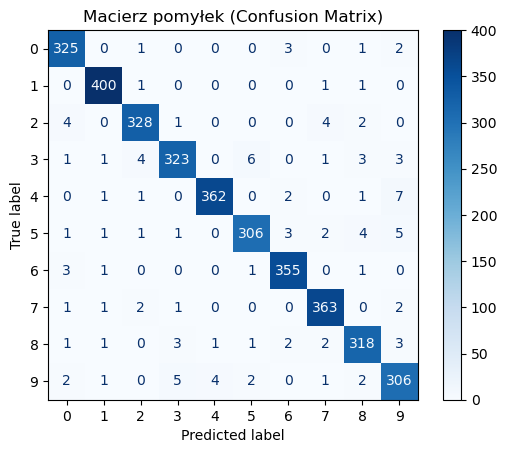

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, recall_score, roc_auc_score

start = time.time()
nn = BatchNeuralNetwork(layers_sizes=[784, 128, 64, 10], act_fun='relu', eta=0.1, max_epochs=300)
nn.train(X_train, y_train)
end = time.time()
print(f"Czas wykonania: {end - start:.3f}s")
y_pred = nn.predict(X_test)

acc = accuracy_score(y_test, y_pred)
sens = recall_score(y_test, y_pred, average='macro')

print(f"Accuracy: {acc:.4f}")
print(f"Sensitivity: {sens:.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Macierz pomyłek (Confusion Matrix)")
plt.show()